<a href="https://colab.research.google.com/github/yejikwon7/DeepLearning/blob/main/final_real.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import datasets, transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, TensorDataset
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import random

os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

# YOLOv5 모델 불러오기 (PyTorch Hub)
yolo_model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)

import sys
sys.path.append('/content/yolov5')  # YOLOv5 경로 추가

Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2024-12-22 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


In [ ]:
from models.common import DetectMultiBackend
from utils.general import non_max_suppression
from utils.torch_utils import select_device

In [ ]:
# matplotlib 설정 초기화
import matplotlib
matplotlib.use('Agg')  # Agg 백엔드로 설정
plt.show()

In [ ]:
# GPU 메모리 관리
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

In [ ]:
# !pip install kaggle
# from google.colab import files
# files.upload()

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sautkin/imagenet1k1")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/sautkin/imagenet1k1/versions/2


In [ ]:
# hyper-parameters
lr = 0.001
epochs = 30
batch_size = 16

In [ ]:
# 데이터셋 경로 설정
train_dir = "/root/.cache/kagglehub/datasets/sautkin/imagenet1k1/versions/2"
val_dir = "/root/.cache/kagglehub/datasets/sautkin/imagenet1k1/versions/2"

# 이미지 경로 수집 함수
def collect_image_paths(directory):
    image_paths = []
    for root, _, files in os.walk(directory):
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png")):  # 이미지 파일 필터링
                image_paths.append(os.path.join(root, file))
    return image_paths

In [ ]:
# 이미지 경로 로드
train_image_paths = collect_image_paths(train_dir)
val_image_paths = collect_image_paths(val_dir)

# 데이터 로드 확인
if not train_image_paths or not val_image_paths:
    raise FileNotFoundError("Train or validation directory contains no images.")

In [ ]:
# 1000개의 데이터를 랜덤하게 샘플링
random.seed(42)
total_image_paths = train_image_paths + val_image_paths
sampled_image_paths = random.sample(total_image_paths, 1000)

In [ ]:
# 데이터셋 정의
class CustomDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label
print(len(sampled_image_paths))

1000


In [ ]:
# 데이터셋 분리
train_size = int(0.6 * len(sampled_image_paths))
val_size = int(0.2 * len(sampled_image_paths))
test_size = len(sampled_image_paths) - train_size - val_size

train_image_paths = sampled_image_paths[:train_size]
val_image_paths = sampled_image_paths[train_size:train_size + val_size]
test_image_paths = sampled_image_paths[train_size + val_size:]

train_labels = [0] * len(train_image_paths)
val_labels = [0] * len(val_image_paths)
test_labels = [0] * len(test_image_paths)

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transforms = val_transforms

train_dataset = CustomDataset(train_image_paths, train_labels, transform=train_transforms)
val_dataset = CustomDataset(val_image_paths, val_labels, transform=val_transforms)
test_dataset = CustomDataset(test_image_paths, test_labels, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

In [ ]:
# YOLO 객체 검출
def extract_objects_with_yolo(yolo_model, dataset, conf_threshold=0.05, min_bbox_size=30):
    cropped_images, labels = [], []
    for img, _ in tqdm(dataset):
        img_pil = transforms.ToPILImage()(img)  # Tensor -> PIL 이미지
        results = yolo_model(img_pil)  # YOLO 추론
        detections = results.xyxy[0].cpu().numpy()  # 검출된 객체

        # Threshold 및 크기 필터링
        for det in detections:
            x1, y1, x2, y2, conf, cls = det
            if conf >= conf_threshold:
                bbox_width, bbox_height = int(x2 - x1), int(y2 - y1)
                if bbox_width > min_bbox_size and bbox_height > min_bbox_size:
                    cropped_img = img_pil.crop((x1, y1, x2, y2))  # 자른 이미지
                    cropped_images.append(cropped_img)
                    labels.append(int(cls))  # 클래스 레이블
    return cropped_images, labels

In [ ]:
# YOLO 객체 검출 실행
cropped_images, yolo_labels = extract_objects_with_yolo(yolo_model, train_dataset, conf_threshold=0.1, min_bbox_size=20)

# 리스트 형태의 yolo_labels를 Tensor로 변환
yolo_labels = torch.tensor(yolo_labels, dtype=torch.long)

# 클래스 레이블 동기화
unique_labels = torch.unique(yolo_labels).tolist()  # Tensor에서 고유 값 추출
class_to_idx = {label: idx for idx, label in enumerate(unique_labels)}

# 라벨 재매핑
yolo_labels = torch.tensor([class_to_idx[label.item()] for label in yolo_labels], dtype=torch.long)

# 클래스 이름 동기화
class_names = [f"Class {i}" for i in range(len(unique_labels))]

print(f"Class Mapping: {class_to_idx}")
print(f"Updated Labels: Min={yolo_labels.min()}, Max={yolo_labels.max()}, Unique={torch.unique(yolo_labels)}")

  0%|          | 0/600 [00:00<?, ?it/s]/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
  0%|          | 1/600 [00:00<04:51,  2.06it/s]/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
WARNING ⚠️ NMS time limit 0.550s exceeded
  0%|          | 2/600 [00:03<18:38,  1.87s/it]/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
  0%|          | 3/600 [00:03<10:34,  1.06s/it]/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.a

Class Mapping: {0: 0, 2: 1, 5: 2, 6: 3, 7: 4, 8: 5, 25: 6, 27: 7, 28: 8, 29: 9, 33: 10, 38: 11, 41: 12, 54: 13, 55: 14, 58: 15, 62: 16, 67: 17, 71: 18, 74: 19, 75: 20, 77: 21, 79: 22}
Updated Labels: Min=0, Max=22, Unique=tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22])


In [ ]:
# ResNet 학습 데이터 생성
resnet_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

resnet_inputs = [resnet_transforms(img) for img in cropped_images]
resnet_labels = torch.tensor(yolo_labels, dtype=torch.long)
resnet_dataset = TensorDataset(torch.stack(resnet_inputs), yolo_labels)
resnet_train_loader = DataLoader(resnet_dataset, batch_size=batch_size, shuffle=True, num_workers=4)

In [ ]:
# ResNet 모델 정의
resnet_model = models.resnet50(pretrained=True)

# 출력 레이어 설정
num_classes = yolo_labels.max().item() + 1  # 레이블의 최대값 + 1로 클래스 수 계산
print(f"Number of classes: {num_classes}")

# 모델 출력 레이어
resnet_model.fc = nn.Sequential(
    nn.Dropout(0.5),  # Dropout 추가
    nn.BatchNorm1d(resnet_model.fc.in_features),  # Batch Normalization 추가
    nn.Linear(resnet_model.fc.in_features, num_classes)
)

# 데이터와 모델 GPU로 전송 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet_model = resnet_model.to(device)

Number of classes: 23


In [ ]:
class DeviceDataLoader:
    def __init__(self, dataloader, device):
        self.dataloader = dataloader
        self.device = device
        self.dataset = dataloader.dataset  # 원래 DataLoader의 dataset 속성 유지

    def __iter__(self):
        for batch in self.dataloader:
            yield (item.to(self.device) for item in batch)

    def __len__(self):
        return len(self.dataloader)

In [ ]:
# 클래스별 샘플 개수 계산
from collections import Counter

class_counts = Counter(yolo_labels.tolist())
class_weights = [1.0 / class_counts[i] for i in range(len(unique_labels))]
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# Weighted Loss 정의
criterion = nn.CrossEntropyLoss(weight=class_weights)

# 손실 함수 및 옵티마이저 정의
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet_model.parameters(), lr=lr, weight_decay=1e-4)
# 스케줄러 정의
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

In [ ]:
# ResNet 학습 함수
def train_model(model, train_loader, val_loader, optimizer, criterion, epochs):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for inputs, labels in tqdm(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            # 데이터 타입 확인
            if labels.dtype != torch.long:
                # print(f"Label dtype mismatch: {labels.dtype}. Converting to torch.long.")
                labels = labels.long()

            optimizer.zero_grad()
            outputs = model(inputs)  # 모델의 순전파 결과

            # 디버깅 출력
            # print(f"Outputs shape: {outputs.shape}, Labels shape: {labels.shape}")
            # print(f"Labels unique: {labels.unique()}")

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        corrects = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                corrects += torch.sum(preds == labels.data)

        val_loss = val_loss / len(val_loader.dataset)
        accuracy = corrects.double() / len(val_loader.dataset)

        val_losses.append(val_loss)
        val_accuracies.append(accuracy.item())

        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, Accuracy: {accuracy:.4f}")

        # 스케줄러 업데이트
        scheduler.step(val_loss)

    return train_losses, val_losses, val_accuracies
# for inputs, labels in resnet_train_loader:
#     print(inputs.device, labels.device)  # GPU로 전송 여부 확인

# print(f"Model output size: {resnet_model.fc.out_features}")
# print(f"Number of classes: {len(set(yolo_labels))}")

In [ ]:
# 학습 실행
train_losses, val_losses, val_accuracies = train_model(resnet_model, resnet_train_loader, val_loader, optimizer, criterion, epochs=epochs)

100%|██████████| 13/13 [00:03<00:00,  3.40it/s]


Epoch 1/30, Train Loss: 44.7120, Val Loss: 32.4745, Accuracy: 0.0000


100%|██████████| 13/13 [00:02<00:00,  4.82it/s]


Epoch 2/30, Train Loss: 40.1247, Val Loss: 4.4992, Accuracy: 0.0100


100%|██████████| 13/13 [00:02<00:00,  4.81it/s]


...

Epoch 28/30, Train Loss: 2.1855, Val Loss: 5.8464, Accuracy: 0.3450


100%|██████████| 13/13 [00:02<00:00,  4.61it/s]


Epoch 29/30, Train Loss: 2.8410, Val Loss: 14.1646, Accuracy: 0.0550


100%|██████████| 13/13 [00:02<00:00,  4.71it/s]


Epoch 30/30, Train Loss: 2.0524, Val Loss: 8.6997, Accuracy: 0.0750


Train Losses: [44.7120239184453, 40.12474164595971, 33.07361048918504, 29.88436350455651, 24.624882349601158, 20.52882681443141, 17.55958738693824, 17.37101163772436, 14.181247967940111, 14.919758539933424, 14.144501346808214, 11.540249806184034, 10.685033752368046, 12.96689536021306, 10.169735019023602, 7.232735292269633, 5.038773605456719, 4.916581082802552, 4.984319508648836, 7.41579230932089, 5.872669160366058, 5.161190000864176, 4.558230084868578, 3.167532068032485, 2.067517748818948, 1.4868976015311022, 1.52494931106384, 2.1854579334075632, 2.840991246012541, 2.052429925936919]
Validation Losses: [32.474459381103514, 4.4991887760162355, 7.704502239227295, 6.078584041595459, 3.5360130500793456, 5.4945768547058105, 6.220887603759766, 9.374816513061523, 2.8309329891204835, 19.36677604675293, 6.143022651672363, 4.749890270233155, 4.12374282836914, 4.4308694553375245, 16.2530534362793, 4.075235576629638, 4.679708642959595, 2.876902770996094, 7.030594596862793, 7.422436828613281, 6.669

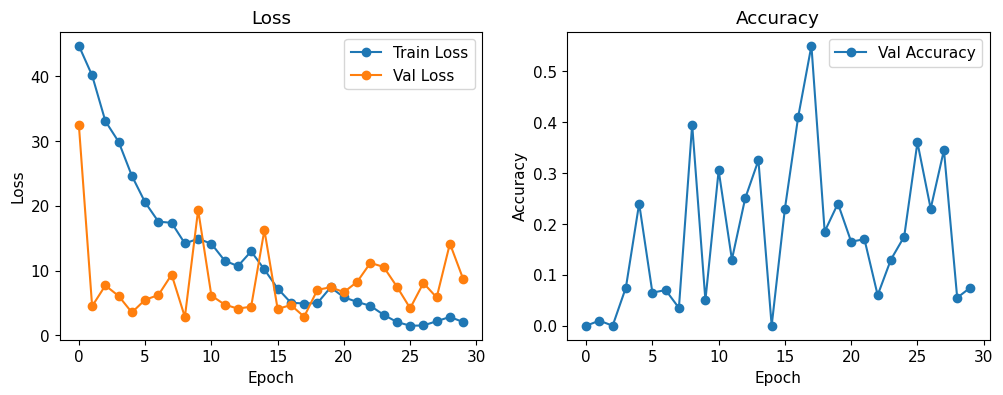

In [ ]:
# 결과 시각화
%matplotlib inline
def plot_metrics(train_losses, val_losses, val_accuracies):
    # 디버깅: 데이터 확인
    print("Train Losses:", train_losses)
    print("Validation Losses:", val_losses)
    print("Validation Accuracies:", val_accuracies)

    # 그래프 설정
    plt.figure(figsize=(12, 4))

    # Loss 그래프
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss', marker='o')
    plt.plot(val_losses, label='Val Loss', marker='o')
    plt.legend()
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    # Accuracy 그래프
    plt.subplot(1, 2, 2)
    plt.plot(val_accuracies, label='Val Accuracy', marker='o')
    plt.legend()
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')

    # 그래프 저장 및 출력
    plt.savefig("metrics_output.png")  # 그래프를 파일로 저장
    plt.show()  # 그래프 렌더링

plot_metrics(train_losses, val_losses, val_accuracies)

In [ ]:
def display_yolo_results(yolo_model, dataset):
    output_dir = "runs/detect/exp"  # YOLO 기본 결과 저장 디렉터리
    os.makedirs(output_dir, exist_ok=True)  # 디렉터리 생성

    for idx, (img, _) in enumerate(dataset):
        img_pil = transforms.ToPILImage()(img)  # Tensor를 PIL 이미지로 변환
        results = yolo_model(img_pil)  # YOLO 실행

        # YOLO 결과 처리
        detections = results.xyxy[0]  # Tensor 형식
        detections = detections.cpu().numpy()  # Numpy 배열로 변환

        # Confidence Threshold 필터링
        detections = [det for det in detections if det[4] >= 0.25]  # 4번째 컬럼이 Confidence

        # 시각화
        if len(detections) > 0:
            plt.figure(figsize=(8, 6))
            plt.imshow(img_pil)
            for det in detections:
                x1, y1, x2, y2, conf, cls = det
                plt.gca().add_patch(
                    plt.Rectangle(
                        (x1, y1),
                        x2 - x1,
                        y2 - y1,
                        fill=False,
                        edgecolor="red",
                        linewidth=2
                    )
                )
                plt.text(
                    x1, y1 - 2, f"{int(cls)}: {conf:.2f}",
                    bbox=dict(facecolor="yellow", alpha=0.5),
                    fontsize=12,
                    color="black"
                )
            plt.axis("off")
            plt.title(f"YOLO Detection: Image {idx}")
            plt.show()
        else:
            print(f"No objects detected in image {idx}")

        # YOLO 결과 저장
        results.save(save_dir=output_dir)

        # 첫 번째 결과만 표시 (추가로 표시하려면 제거 가능)
        break

In [ ]:
def display_resnet_results(model, test_loader, class_names):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    for idx, (inputs, labels) in enumerate(test_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        # 이미지 및 결과 시각화
        for i in range(min(len(inputs), 5)):  # 최대 5개 이미지 출력
            true_label = labels[i].item()
            pred_label = preds[i].item()

            if true_label >= len(class_names) or pred_label >= len(class_names):
                print(f"Label out of range: True={true_label}, Predicted={pred_label}")
                continue

            plt.title(f"True: {class_names[true_label]}, Predicted: {class_names[pred_label]}")
            plt.imshow(inputs[i].cpu().permute(1, 2, 0))  # Tensor를 이미지로 변환
            plt.axis("off")
            plt.show()

        if idx == 0:  # 첫 번째 배치만 출력
            break

In [ ]:
from PIL import Image
img = Image.open("metrics_output.png")
img.show()  # 이미지 확인

In [ ]:
# 필요한 모듈 임포트
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# 테스트 모델 실행 함수
def test_model_with_yolo_and_resnet(yolo_model, resnet_model, test_loader, resnet_transforms):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    resnet_model.eval()
    yolo_model.eval()

    all_preds = []
    all_labels = []

    for inputs, labels in tqdm(test_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        img_pil = transforms.ToPILImage()(inputs[0].cpu())  # Tensor -> PIL 이미지
        results = yolo_model(img_pil)

        detections = results.xyxy[0].cpu().numpy()
        for det in detections:
            x1, y1, x2, y2, conf, cls = det
            if conf >= 0.05:
                cropped_img = img_pil.crop((x1, y1, x2, y2))
                transformed_img = resnet_transforms(cropped_img).unsqueeze(0).to(device)
                with torch.no_grad():
                    outputs = resnet_model(transformed_img)
                    _, preds = torch.max(outputs, 1)
                    all_preds.append(preds.item())
                    all_labels.append(int(cls))  # YOLO에서 검출된 클래스 레이블 사용

    # Confusion Matrix 생성 및 출력
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(len(set(all_labels)))))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="viridis")
    plt.title("Confusion Matrix")
    plt.show()

    # 성능 지표 계산
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    print(f"Test Accuracy: {accuracy:.2%}")
    print(f"Precision: {precision:.2f}, Recall: {recall:.2f}, F1 Score: {f1:.2f}")

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
Saved 1 image to runs/detect/exp10


Displaying YOLO Results...
No objects detected in image 0
Displaying ResNet Results...


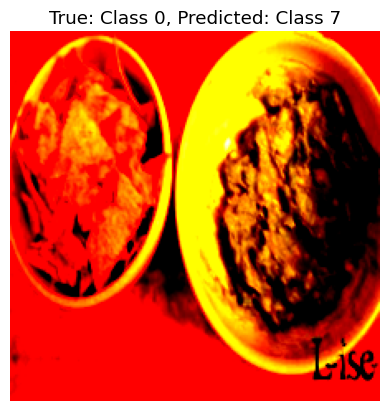

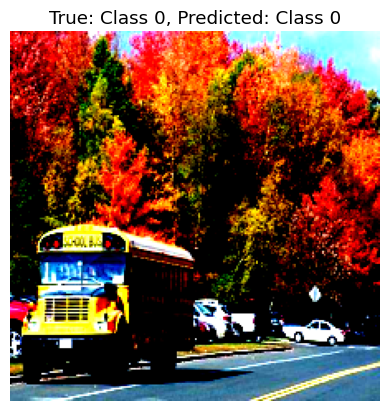

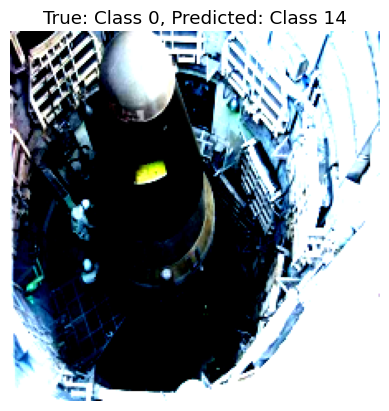

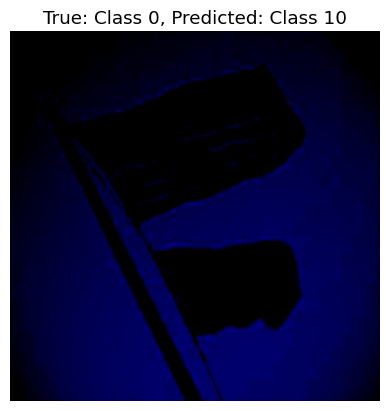

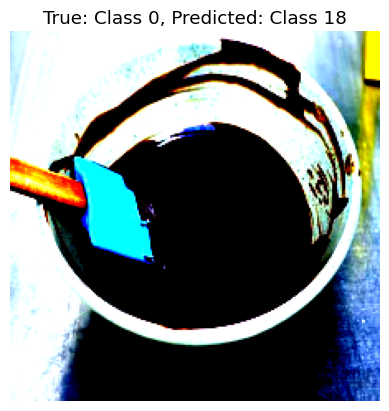

In [ ]:
# YOLO 결과 시각화
print("Displaying YOLO Results...")
display_yolo_results(yolo_model, train_dataset)

# ResNet 테스트 결과 시각화
print("Displaying ResNet Results...")
unique_classes = sorted(set(yolo_labels.cpu().numpy()))  # 고유 클래스 정렬
class_names = [f"Class {i}" for i in unique_classes]  # 고유 클래스만으로 이름 생성
display_resnet_results(resnet_model, test_loader, class_names)

  0%|          | 0/13 [00:00<?, ?it/s]/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
  8%|▊         | 1/13 [00:02<00:24,  2.08s/it]/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
 15%|█▌        | 2/13 [00:02<00:11,  1.06s/it]/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
 23%|██▎       | 3/13 [00:02<00:06,  1.47it/s]/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `t

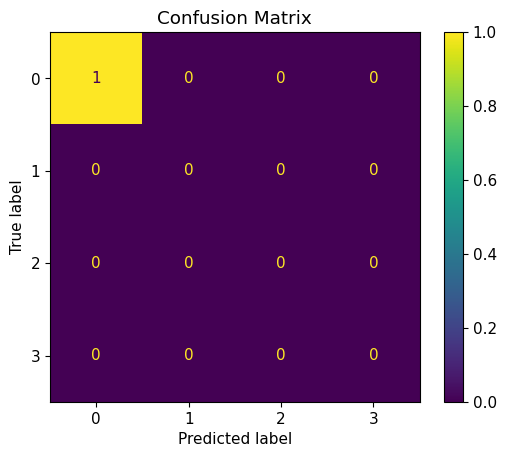

Test Accuracy: 16.67%
Precision: 0.14, Recall: 0.14, F1 Score: 0.14
Precision: 0.09, Recall: 0.01, F1 Score: 0.02


In [ ]:
# 클래스 이름 정의
class_names = None

# 테스트 실행
test_model_with_yolo_and_resnet(yolo_model, resnet_model, test_loader, resnet_transforms)